In this lab, you will implementat a neural network using the Keras library for the Fashion MNIST dataset. 

These are the steps: 

1. Import necessary libraries
2. Load the dataset
3. Print the shape
4. Data Preprocessing:
- Reshape the input data from 28x28 images to a flat vector of size 784.
- Normalize the pixel values to the range [0, 1].
- Convert class labels to one-hot encoded vectors.
5. Build the Neural Network Model
- Create a sequential model using Keras.
- Add a dense layer with 64 neurons and a sigmoid activation function.
- Add an output layer with 10 neurons (for 10 classes) and a softmax activation function.
6. Compile the model using mean squared error as the loss function and stochastic gradient descent (SGD) as the optimizer.
7. Train the model
- Use 100 epochs and a batch size of 128.
8. Display a summary of the model architecture.
9. Evaluate the model on the validation set and print the accuracy.
10. Prot the Confusion Matrix
11. Visualize the Predictions
12. Make predictions on the validation set and display the predicted class probabilities for a specific example.

### Import Libraries: numpy, matplotlib
- from keras.datasets import fashion_mnist
- from keras.models import Sequential
- from keras.layers import Dense
- from tensorflow.keras.optimizers import SGD
- from keras.utils import to_categorical

In [1]:
#from keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from keras.utils import to_categorical

### Load the data into these variables:   (X_train, y_train), (X_valid, y_valid)

In [2]:
(X_train, y_train), (X_valid, y_valid) = fashion_mnist.load_data()

4422102/4422102 [==============================] - 0s 0us/step


#### Print a random image from the dataset
feel free to use: np.random.randint (0, X_train.shape[0])

In [3]:
#sample = 
sample = np.random.randint(0, X_train.shape[0])
sample

32492

#### Plot the image 
#### See sample below for sample 39235. Most likely, your image will be different.

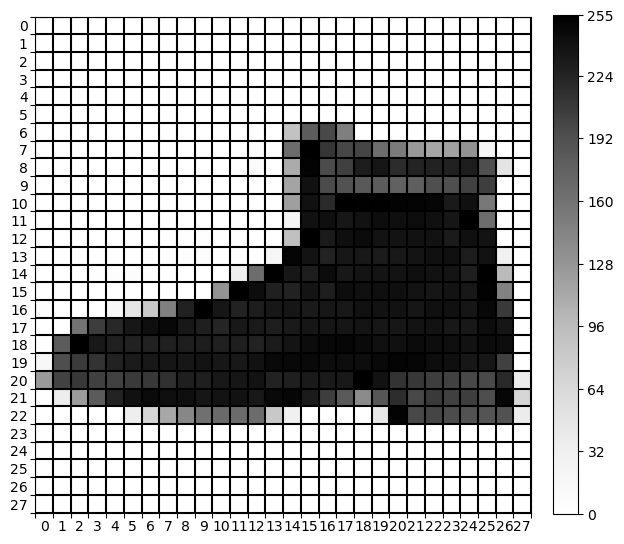

In [51]:
plt.figure(figsize = (7,7))
mnist_img = X_train[sample]
plt.imshow(mnist_img,cmap="Greys")
ax = plt.gca()

# First turn off the  major labels, but not the major ticks
plt.tick_params(
    axis='both',        # changes apply to the both x and y axes
    which='major',      # Change the major ticks only
    bottom=True,        # ticks along the bottom edge are on
    left=True,          # ticks along the top edge are on
    labelbottom=False,  # labels along the bottom edge are off
    labelleft=False)    # labels along the left edge are off

# Next turn off the minor ticks, but not the minor labels
plt.tick_params(
    axis='both',        # changes apply to both x and y axes
    which='minor',      # Change the minor ticks only
    bottom=False,       # ticks along the bottom edge are off
    left=False,         # ticks along the left edge are off
    labelbottom=True,   # labels along the bottom edge are on
    labelleft=True)     # labels along the left edge are on

# Set the major ticks, starting at 1 (the -0.5 tick gets hidden off the canvas)
ax.set_xticks(np.arange(-.5, 28, 1))
ax.set_yticks(np.arange(-.5, 28, 1))

# Set the minor ticks and labels
ax.set_xticks(np.arange(0, 28, 1), minor=True);
ax.set_xticklabels([str(i) for i in np.arange(0, 28, 1)], minor=True);
ax.set_yticks(np.arange(0, 28, 1), minor=True);
ax.set_yticklabels([str(i) for i in np.arange(0, 28, 1)], minor=True);

ax.grid(color='black', linestyle='-', linewidth=1.5)
_ = plt.colorbar(fraction=0.046, pad=0.04, ticks=[0,32,64,96,128,160,192,224,255])

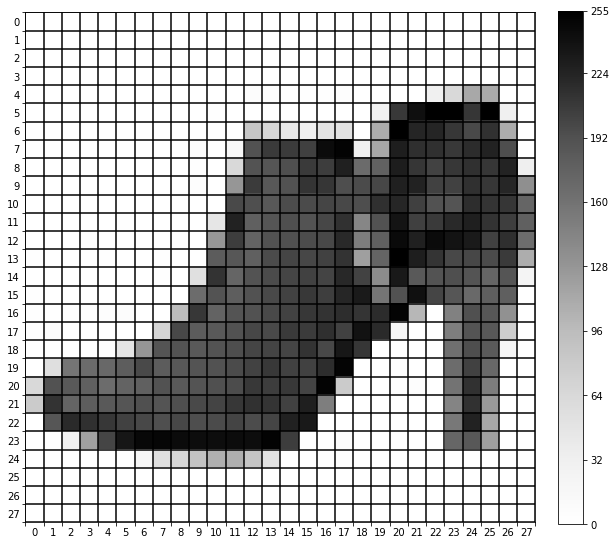

#### Confirm image label
#### you will get a number from (0 to 9).

In [52]:
y_train[sample]

9

### Plot the image  in a matrix format
Use precision, suppress, and linewidth

In [53]:
np.set_printoptions(precision=2, suppress=True, linewidth=120)
print(np.matrix(X_train[sample]))

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   4   0  89 181 197 148   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   7   0 166 255 211 199 200 165 152 125 114 119 130  22   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   7   0 110 252 196 204 230 23

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   5   4   1   1   2   3   0   0   0   0  30  63 112 111   0   0]
 [  0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0  26 209 242 255 255 211 255  30   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  85  66  44  31  49  50   0 109 255 223 223 210 197 214 109   0]
 [  0   0   0   0   0   0   0   0   0   5   0  13 191 208 207 204 245 252  30 112 229 216 215 209 218 225 194   0]
 [  0   0   0   0   0   0   0   0   0   2   0  63 190 188 193 208 206 227 167 17

#### Rename the labels (class_names) 
#### from (0,1,2,3...,9) to ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

In [55]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

### Print the shape of the train and test images and labes  
i.e. X_train.shape

In [66]:
print("train_images.shape:", X_train.shape)
print("len(train_labels):", len(y_train))
print("test_images.shape:", X_valid.shape)
print("len(test_labels):", len(y_valid))

train_images.shape: (60000, 28, 28)
len(train_labels): 60000
test_images.shape: (10000, 28, 28)
len(test_labels): 10000


In [9]:
# It should look like this:

train_images.shape: (60000, 28, 28)
len(train_labels: 60000
test_images.shape: (10000, 28, 28)
len(test_labels): 10000


#### Plot several images showing the new label

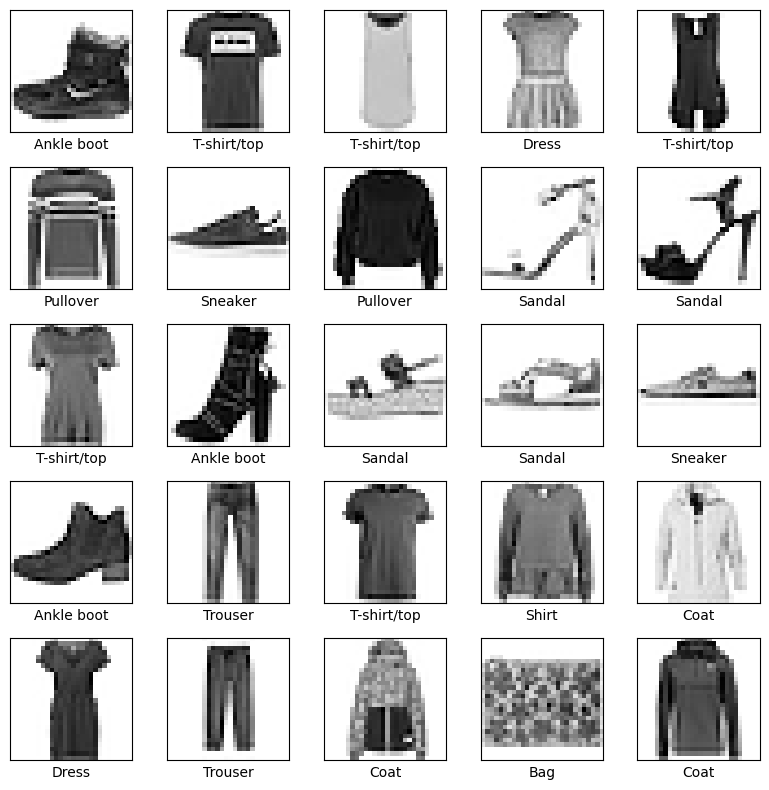

In [84]:
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap='Greys')
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

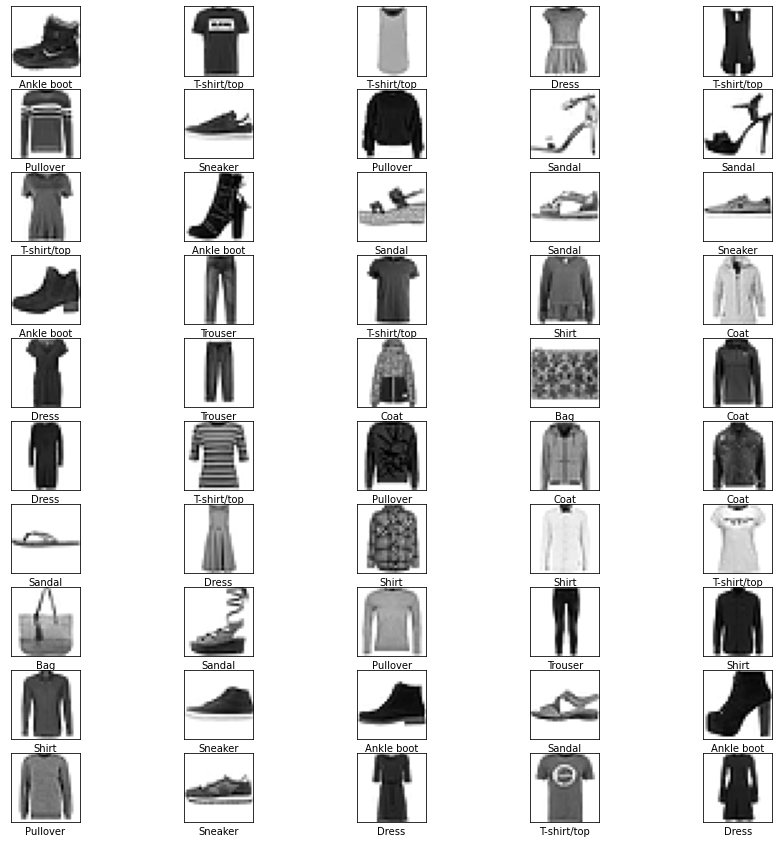

In [10]:
# sample

## Shallow Neural Network in Keras

### Plot some images without the label

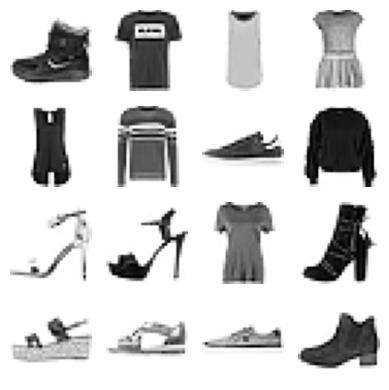

In [88]:
plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    plt.grid(False)
    plt.imshow(X_train[i], cmap='Greys')
plt.tight_layout()
plt.show()

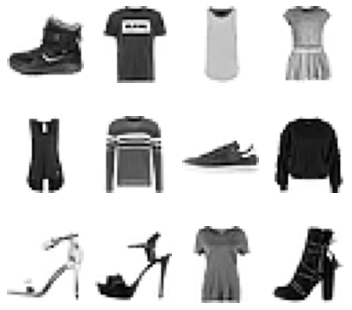

In [12]:
#sample

### Plot the first image
X_valid[0]

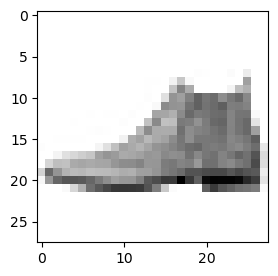

In [104]:
plt.figure(figsize = (3,3))
plt.imshow(X_valid[0], cmap='Greys')

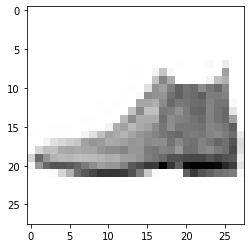

In [13]:
# sample

### Validate that the label is a 9
y_valid[0]

In [91]:
y_valid[0]

9

### Preprocess data

- After you load in the images, reshape them from a two-dimensional 28x28 shape to a one-dimensional array of 784 elements (28 x 28 = 784)
- Use the as type ('float32') to convert the pixel darknesses from integers into single-precision float values.

In [105]:
X_train = X_train.reshape(60000, 784).astype('float32')
X_valid = X_valid.reshape(10000, 784).astype('float32')

### Converting pixel intergers to floats
devide by 255.0

In [106]:
X_train /= 255
X_valid /= 255

### convert the label y (y_train,y_valid) from integers into one-hot encodings
n_classes = 10

In [107]:
n_classes = 10
y_train = to_categorical(y_train, n_classes)
y_valid = to_categorical(y_valid, n_classes)

### display the values of y_valid

In [108]:
y_valid

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [18]:
# sample

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

### Design neural network architecture

- Create a Sequential model and call it "model"
- For the hidden layer, use the add() method with 64 neurons and activation = 'sigmoid' with an input_shape=(784,0)
- For the output layer, use the add() method with 10 neurons and the softmax activation function

In [112]:
model = Sequential()
model.add(Dense(64, activation='sigmoid', input_shape=(784,)))
model.add(Dense(10, activation='softmax'))

### Display the summary of the model and explain what the numbers mean

In [113]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 64)                50240     
                                                                 
 dense_3 (Dense)             (None, 10)                650       
                                                                 
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
_________________________________________________________________


In [20]:
# sample

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dense_1 (Dense)             (None, 10)                650       
                                                                 
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
_________________________________________________________________


### Compile the model using:
- loss="categorical_crossentropy"
- Set the cost-minimizing method to stochastic gradient descent by using optimizer = SGD
- Specify the SGD learning rate hyperparameter equals to 0.01
- Set the metrics to 'accurancy' to recieve feedbak on model accurancy

In [115]:
model.compile(loss='categorical_crossentropy', optimizer = SGD(learning_rate=0.01), metrics=['accuracy'])

### Training the data 
### Fit the model using a batch_size = 128 and 100 epochs
- model.fit()
- set batch_size = 128
- set verbove = 1
- set epochs = 100
- validate the data

In [117]:
model.fit(X_train, y_train, batch_size=128, verbose=1, epochs=100, validation_data=(X_valid, y_valid))

Epoch 1/100
469/469 [==============================] - 3s 4ms/step - loss: 1.8762 - accuracy: 0.5238 - val_loss: 1.5514 - val_accuracy: 0.6289
Epoch 2/100
469/469 [==============================] - 2s 3ms/step - loss: 1.3579 - accuracy: 0.6837 - val_loss: 1.2167 - val_accuracy: 0.7020
Epoch 3/100
469/469 [==============================] - 1s 3ms/step - loss: 1.1157 - accuracy: 0.7171 - val_loss: 1.0455 - val_accuracy: 0.7109
Epoch 4/100
469/469 [==============================] - 1s 3ms/step - loss: 0.9797 - accuracy: 0.7296 - val_loss: 0.9405 - val_accuracy: 0.7226
Epoch 5/100
469/469 [==============================] - 1s 3ms/step - loss: 0.8917 - accuracy: 0.7390 - val_loss: 0.8694 - val_accuracy: 0.7321
Epoch 6/100
469/469 [==============================] - 2s 3ms/step - loss: 0.8297 - accuracy: 0.7466 - val_loss: 0.8176 - val_accuracy: 0.7399
Epoch 7/100
469/469 [==============================] - 2s 3ms/step - loss: 0.7834 - accuracy: 0.7535 - val_loss: 0.7781 - val_accuracy: 0.7440

Epoch 58/100
469/469 [==============================] - 2s 3ms/step - loss: 0.4461 - accuracy: 0.8446 - val_loss: 0.4755 - val_accuracy: 0.8314
Epoch 59/100
469/469 [==============================] - 2s 3ms/step - loss: 0.4446 - accuracy: 0.8445 - val_loss: 0.4744 - val_accuracy: 0.8318
Epoch 60/100
469/469 [==============================] - 2s 3ms/step - loss: 0.4432 - accuracy: 0.8447 - val_loss: 0.4731 - val_accuracy: 0.8342
Epoch 61/100
469/469 [==============================] - 1s 3ms/step - loss: 0.4418 - accuracy: 0.8454 - val_loss: 0.4727 - val_accuracy: 0.8324
Epoch 62/100
469/469 [==============================] - 1s 3ms/step - loss: 0.4404 - accuracy: 0.8454 - val_loss: 0.4707 - val_accuracy: 0.8325
Epoch 63/100
469/469 [==============================] - 2s 3ms/step - loss: 0.4391 - accuracy: 0.8462 - val_loss: 0.4693 - val_accuracy: 0.8338
Epoch 64/100
469/469 [==============================] - 1s 3ms/step - loss: 0.4378 - accuracy: 0.8467 - val_loss: 0.4683 - val_accuracy:

### Evaluate the model

In [118]:
model.evaluate(X_valid, y_valid)

313/313 [==============================] - 1s 2ms/step - loss: 0.4390 - accuracy: 0.8427


[0.4389716386795044, 0.8427000045776367]

### Create a function to prin the confusion matrix
### Feel free to use this function below or do your own one

### Explain the confusion Matrix with your own words

### Import Libraries   
- From collections input Counter
- Import confusion_matrix from sklearn
- import itertoos

In [119]:
from collections import Counter
from sklearn.metrics import confusion_matrix
import itertools

In [120]:
# Look at confusion matrix 
#Note, this code is taken straight from the SKLEARN website, an nice way of viewing confusion matrix.
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Observación')
    plt.xlabel('Predicción')

313/313 [==============================] - 1s 2ms/step


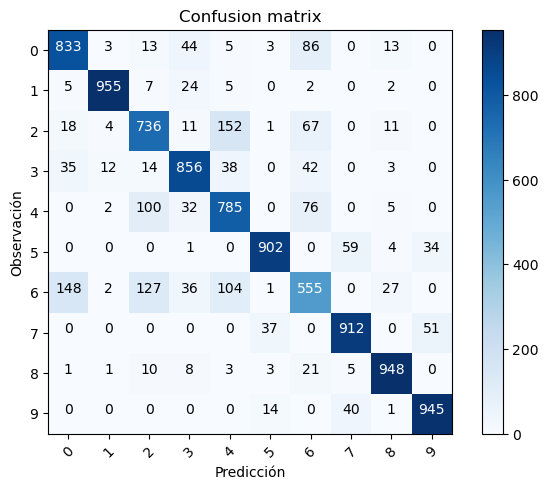

In [121]:
# Predict the values from the validation dataset
Y_pred = model.predict(X_valid)
# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_pred, axis = 1) 
# Convert validation observations to one hot vectors
Y_true = np.argmax(y_valid, axis = 1) 
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 
# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(10))

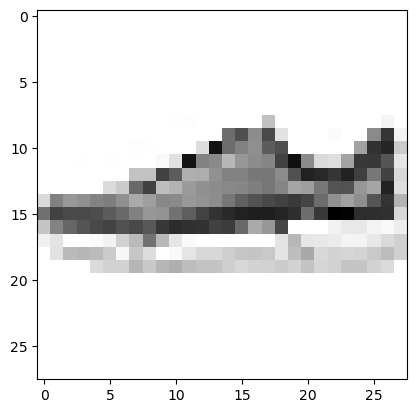

In [122]:
x_test_old = X_valid.reshape(10000, 28,28)
plt.imshow(x_test_old[9], cmap=plt.cm.binary)

In [124]:
predictions = model.predict(X_valid)

313/313 [==============================] - 1s 2ms/step


In [125]:
np.argmax(predictions[9])

7

In [126]:
print(predictions[9])

[0.   0.   0.   0.   0.   0.02 0.   0.98 0.   0.  ]


In [127]:
np.sum(predictions[9])

1.0000001

#### Explain the results of the confusion matrix with your own words

The x-axis labeled "Predicción" represents the predicted classes (0-9).
The y-axis labeled "Observación" represents the actual (true) classes (0-9).
Color Intensity:
    Darker blue colors represent higher values, indicating that the classifier made more predictions for that class pairing
    Lighter colors or near-white cells indicate lower values, showing fewer predictions.
    
Category 0: 833 instances were true class was 0 and classifier predicted 0<br>
Category 1: 955 instances were true class was 1 and classifier predicted 1<br>
Category 2: 736 instances were true class was 2 and classifier predicted 2<br>
Category 3: 856 instances were true class was 3 and classifier predicted 3<br>
Category 4: 785 instances were true class was 4 and classifier predicted 4<br>
Category 5: 902 instances were true class was 5 and classifier predicted 5<br>
Category 6: 555 instances were true class was 6 and classifier predicted 6<br>
Category 7: 912 instances were true class was 7 and classifier predicted 7<br>
Category 8: 948 instances were true class was 8 and classifier predicted 8<br>
Category 9: 945 instances were true class was 9 and classifier predicted 9<br>

The model performs relatively well on most classes, as seen by the high values along the diagonal.  However, there are specific classes that are misclassified more often.  Class 6 was mistaken for class 0 148 times, class 2 127 times, and class 4 104 times.  This suggests that these classes share similar features, making it harder to distinguish between them.

This confusion matrix helps identify the strengths and weaknesses, showing that it performs well overall but has difficulty distinguishing certain classes.

#### Finally, Plot the ReLU function

## The Rectified Linear Unit function

The Rectified Linear Unit (ReLU) function is another one of the most commonly used
activation functions. It outputs a value from o to infinity. It is basically a piecewise function
and can be expressed as follows: 
    

$$ f(x)=\left\{\begin{array}{ll}{0} & {\text { for } x<0} \\ {x} & {\text { for } x \geq 0}\end{array}\right.$$
               
               
That is, $f(x)$ returns zero when the value of x is less than zero and $f(x)$ returns x when the
value of x is greater than or equal to zero. It can also be expressed as follows: 

$$ f(x)=\max (0, x)$$


#### Create a ReLU function

In [128]:
def ReLU(x):
    if x<0:
        return 0
    else:
        return x

#### Test the function with a positve value and a negative value

In [129]:
#Postivie
ReLU(4)

4

In [130]:
#Negative
ReLU(-4)

0

### Plot the ReLU function.

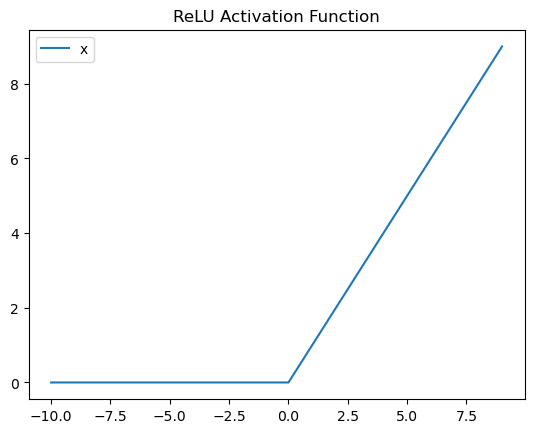

In [155]:
#Generate the data for the plot
x_data = []
y_data = []

for x in range(-10, 10):
    x_data.append(x)
    y_data.append(ReLU(x))

#Plot the function
plt.title('ReLU Activation Function')
plt.plot(x_data, y_data)
plt.legend('x')
plt.show()